In [3]:
import numpy as np
from PIL import Image
def fractal_dimension(Z, threshold=0.9):
    # Only for 2d image
    assert(len(Z.shape) == 2)

    # From https://github.com/rougier/numpy-100 (#87)
    def boxcount(Z, k):
        S = np.add.reduceat(
            np.add.reduceat(Z, np.arange(0, Z.shape[0], k), axis=0),
                               np.arange(0, Z.shape[1], k), axis=1)

        # We count non-empty (0) and non-full boxes (k*k)
        return len(np.where((S > 0) & (S < k*k))[0])

    # Transform Z into a binary array
    Z = (Z < threshold)

    # Minimal dimension of image
    p = min(Z.shape)

    # Greatest power of 2 less than or equal to p
    n = 2**np.floor(np.log(p)/np.log(2))

    # Extract the exponent
    n = int(np.log(n)/np.log(2))

    # Build successive box sizes (from 2**n down to 2**1)
    sizes = 2**np.arange(n, 1, -1)

    # Actual box counting with decreasing size
    counts = []
    for size in sizes:
        counts.append(boxcount(Z, size))

    # Fit the successive log(sizes) with log (counts)
    coeffs = np.polyfit(np.log(sizes), np.log(counts), 1)
    return -coeffs[0]

def fractal_noise_2d(shape=(256, 256), beta=1, seed=None, normalize=True):
    """
    Generate a 2D fractal (1/f^β) noise image.

    Parameters:
        shape: (int, int) -- image size (height, width)
        beta: float       -- spectral exponent (0=white, 1=pink, 2=brown)
        seed: int or None -- random seed
        normalize: bool   -- if True, output is scaled to [0, 1]
    Returns:
        img: 2D numpy array
    """
    if seed is not None:
        np.random.seed(seed)
    h, w = shape
    # Make frequency grid
    fy = np.fft.fftfreq(h).reshape(-1, 1)
    fx = np.fft.fftfreq(w).reshape(1, -1)
    freq = np.sqrt(fx**2 + fy**2)
    # Set the DC (zero freq) to avoid division by zero
    freq[0,0] = 1.0
    # Amplitude spectrum ~ 1/f^beta
    amplitude = 1 / (freq ** (beta / 2.0))
    # Generate random phases
    phase = np.exp(2j * np.pi * np.random.rand(h, w))
    # Combine amplitude and phase
    fourier_field = amplitude * phase
    # Inverse FFT to get spatial image
    img = np.fft.ifft2(fourier_field).real
    # Remove any DC offset (mean)
    img = img - img.mean()
    # Optionally normalize to [0,1]
    if normalize:
        img = (img - img.min()) / (img.max() - img.min())
    return img

def plasma_fractal(size=256, roughness=0.7, seed=None):
    np.random.seed(seed)
    def diamond_square(grid, step, scale):
        half = step // 2
        for y in range(half, size, step):
            for x in range(half, size, step):
                c = (grid[y-half,x-half] + grid[y-half,x+half] + grid[y+half,x-half] + grid[y+half,x+half]) / 4
                grid[y,x] = c + np.random.uniform(-scale, scale)
        for y in range(0, size, half):
            for x in range((y+half)%step, size, step):
                s = []
                for dx,dy in [(-half,0),(half,0),(0,-half),(0,half)]:
                    xx,yy = x+dx, y+dy
                    if 0 <= xx < size and 0 <= yy < size:
                        s.append(grid[yy,xx])
                avg = np.mean(s)
                grid[y,x] = avg + np.random.uniform(-scale, scale)
    grid = np.zeros((size, size))
    grid[0,0] = grid[0,-1] = grid[-1,0] = grid[-1,-1] = 0.5
    step, scale = size-1, roughness
    while step > 1:
        diamond_square(grid, step, scale)
        step //= 2
        scale *= roughness
    return (grid - grid.min()) / (grid.max() - grid.min())


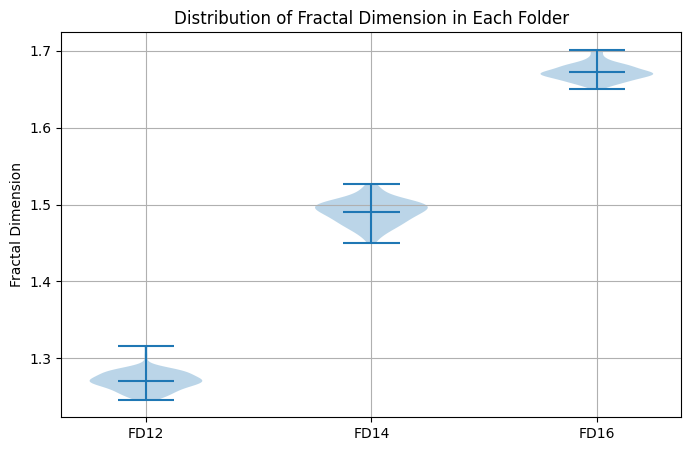

In [5]:
import os
import matplotlib.pyplot as plt

# --- Main code ---
root_folder = "../images"
fd_folders = ["FD12", "FD14", "FD16"]
fd_dict = {fd: [] for fd in fd_folders}

for fd_folder in fd_folders:
    folder_path = os.path.join(root_folder, fd_folder)
    for fname in os.listdir(folder_path):
        if not fname.lower().endswith((".png", ".jpg", ".jpeg", ".bmp", ".tif", ".tiff")):
            continue
        img_path = os.path.join(folder_path, fname)
        img = Image.open(img_path).convert("L").resize((256, 256), Image.NEAREST)
        img_array = np.array(img)
        # Adjust threshold for your images: 0.1 for [0,1] float; 25 for uint8? Test!
        fd = fractal_dimension(img_array, threshold=0.1)
        fd_dict[fd_folder].append(fd)

# --- Plotting ---
labels = []
data = []
for fd_folder in fd_folders:
    data.append(fd_dict[fd_folder])
    labels.append(fd_folder)

plt.figure(figsize=(8,5))
plt.violinplot(data, showmeans=True)
plt.xticks([1,2,3], labels)
plt.ylabel("Fractal Dimension")
plt.title("Distribution of Fractal Dimension in Each Folder")
plt.grid(True)
plt.show()

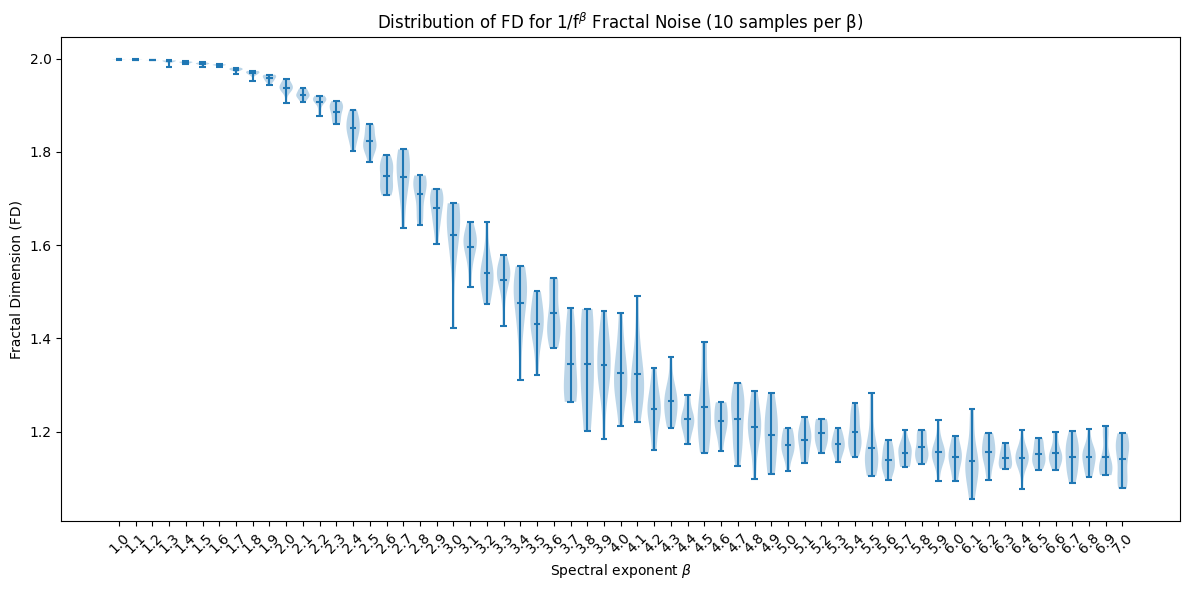

In [71]:
# Generate images and compute FDs
betas = np.arange(1, 7.01, 0.1)
fd_results = []

for beta in betas:
    fd_beta = []
    for i in range(10):
        img = fractal_noise_2d((256, 256), beta=beta, seed=None)
        binary = (img > 0.5).astype(np.float32)
        fd = fractal_dimension(binary, threshold=0.5)
        fd_beta.append(fd)
    fd_results.append(fd_beta)

# Plot distributions
plt.figure(figsize=(12,6))
plt.violinplot(fd_results, showmeans=True, widths=0.8)
plt.xticks(np.arange(1, len(betas)+1), [f"{b:.1f}" for b in betas], rotation=45)
plt.xlabel(r"Spectral exponent $\beta$")
plt.ylabel("Fractal Dimension (FD)")
plt.title("Distribution of FD for 1/f$^{\u03B2}$ Fractal Noise (10 samples per β)")
plt.tight_layout()
plt.show()

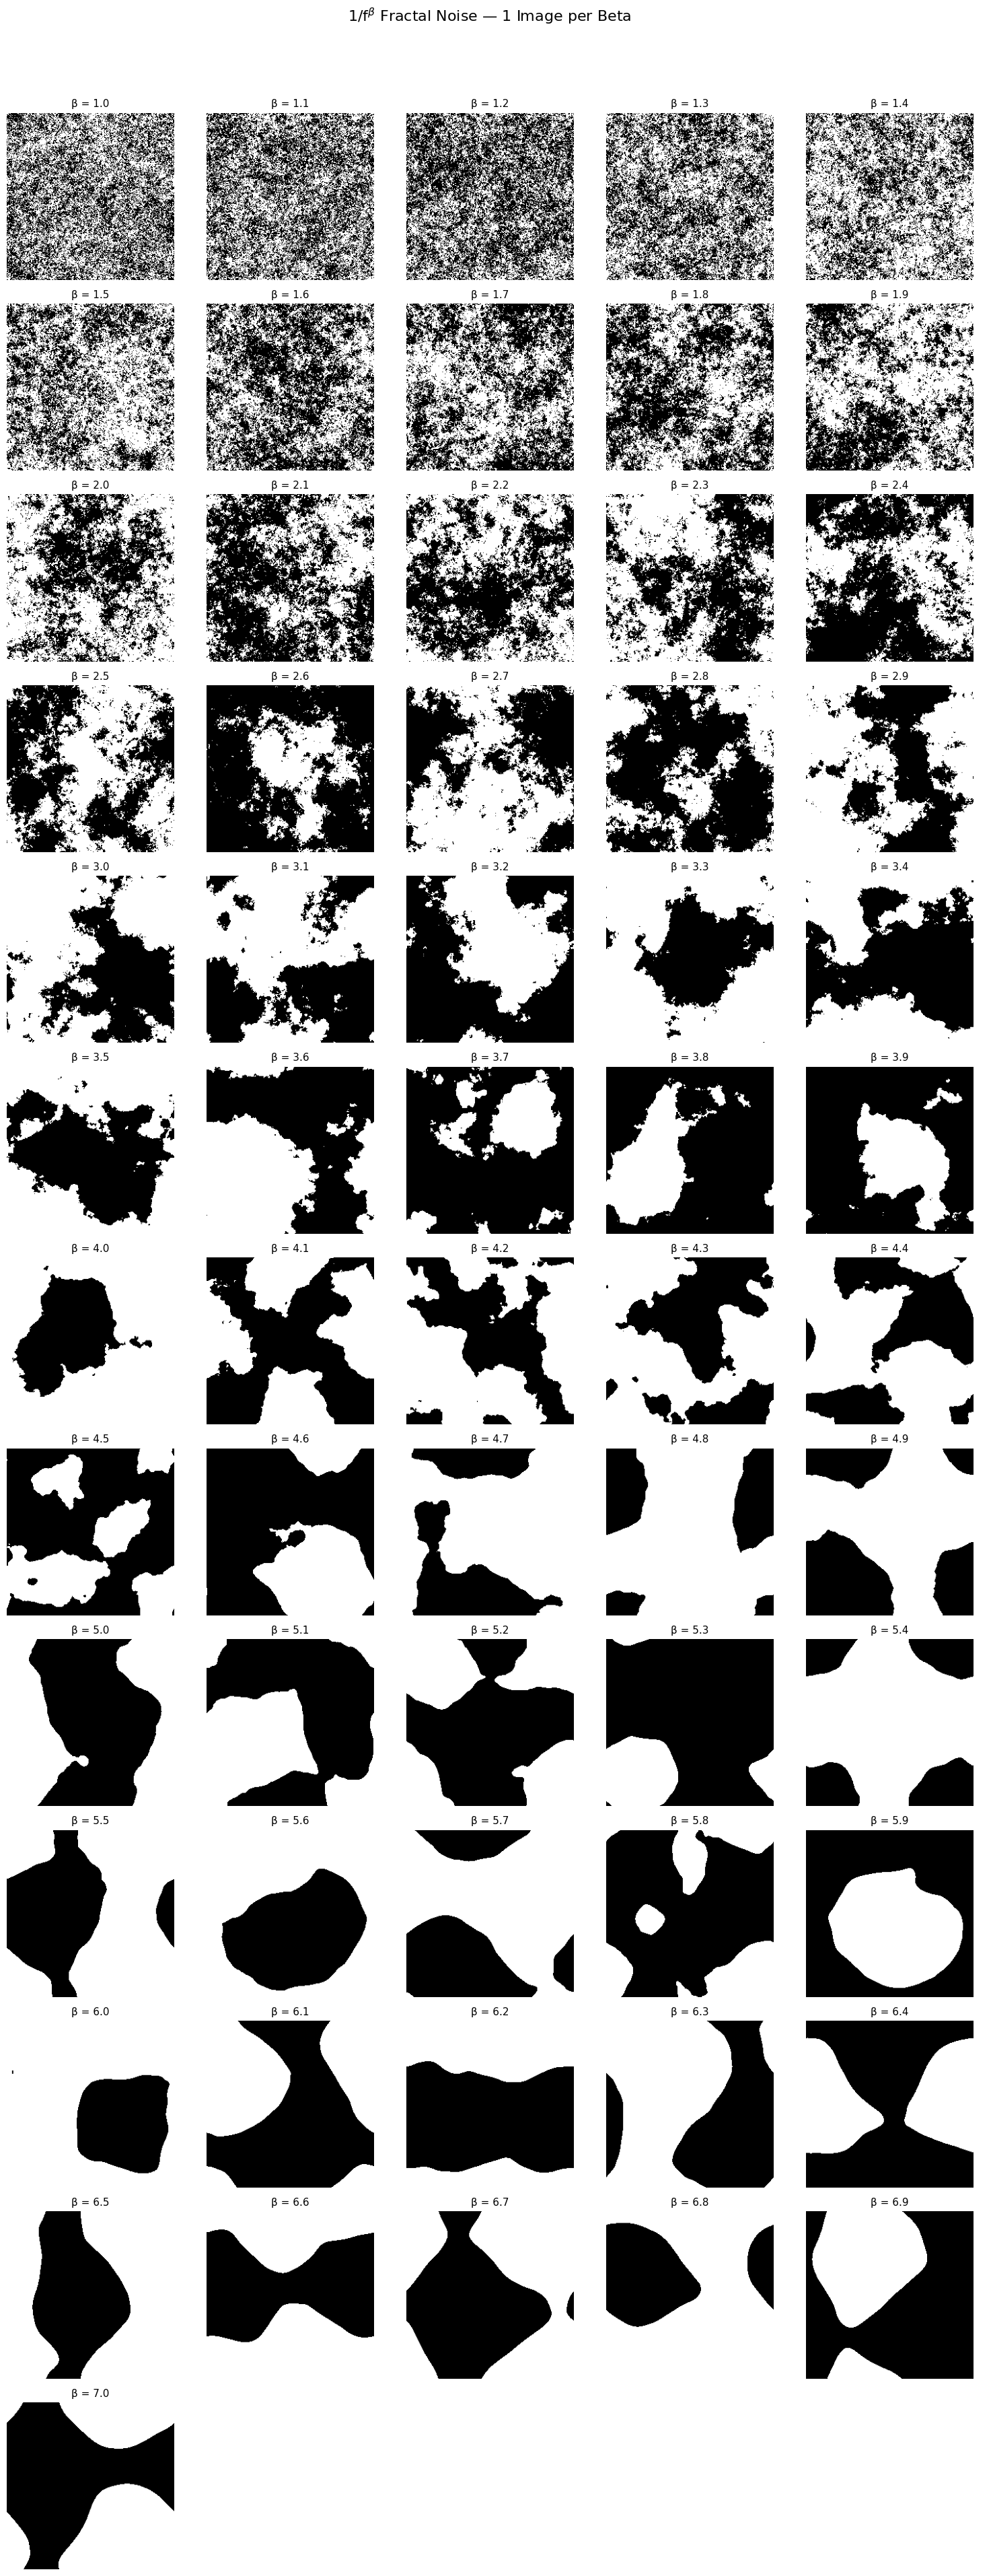

In [79]:
import numpy as np
import matplotlib.pyplot as plt


# How many images per row?
n_cols = min(5, len(betas))
n_rows = int(np.ceil(len(betas) / n_cols))

fig, axes = plt.subplots(n_rows, n_cols, figsize=(3*n_cols, 3*n_rows))
axes = axes.flatten()

for i, beta in enumerate(betas):
    img = fractal_noise_2d((256, 256), beta=beta)
    binary = (img > 0.5).astype(np.float32)
    axes[i].imshow(binary, cmap='gray', vmin=0, vmax=1)
    axes[i].set_title(f"β = {beta:.1f}", fontsize=11)
    axes[i].axis('off')

# Hide any unused subplots
for j in range(i+1, len(axes)):
    axes[j].axis('off')

plt.suptitle("1/f$^{\\beta}$ Fractal Noise — 1 Image per Beta", fontsize=16)
plt.tight_layout(rect=[0,0,1,0.96])
plt.show()


# Fractal plasma

Generating plasma fractal with roughness 0.30, sample 1/10
Generating plasma fractal with roughness 0.30, sample 2/10
Generating plasma fractal with roughness 0.30, sample 3/10
Generating plasma fractal with roughness 0.35, sample 1/10
Generating plasma fractal with roughness 0.35, sample 2/10
Generating plasma fractal with roughness 0.35, sample 3/10
Generating plasma fractal with roughness 0.40, sample 1/10
Generating plasma fractal with roughness 0.40, sample 2/10
Generating plasma fractal with roughness 0.40, sample 3/10
Generating plasma fractal with roughness 0.45, sample 1/10
Generating plasma fractal with roughness 0.45, sample 2/10
Generating plasma fractal with roughness 0.45, sample 3/10
Generating plasma fractal with roughness 0.50, sample 1/10
Generating plasma fractal with roughness 0.50, sample 2/10
Generating plasma fractal with roughness 0.50, sample 3/10
Generating plasma fractal with roughness 0.55, sample 1/10
Generating plasma fractal with roughness 0.55, sample 2/

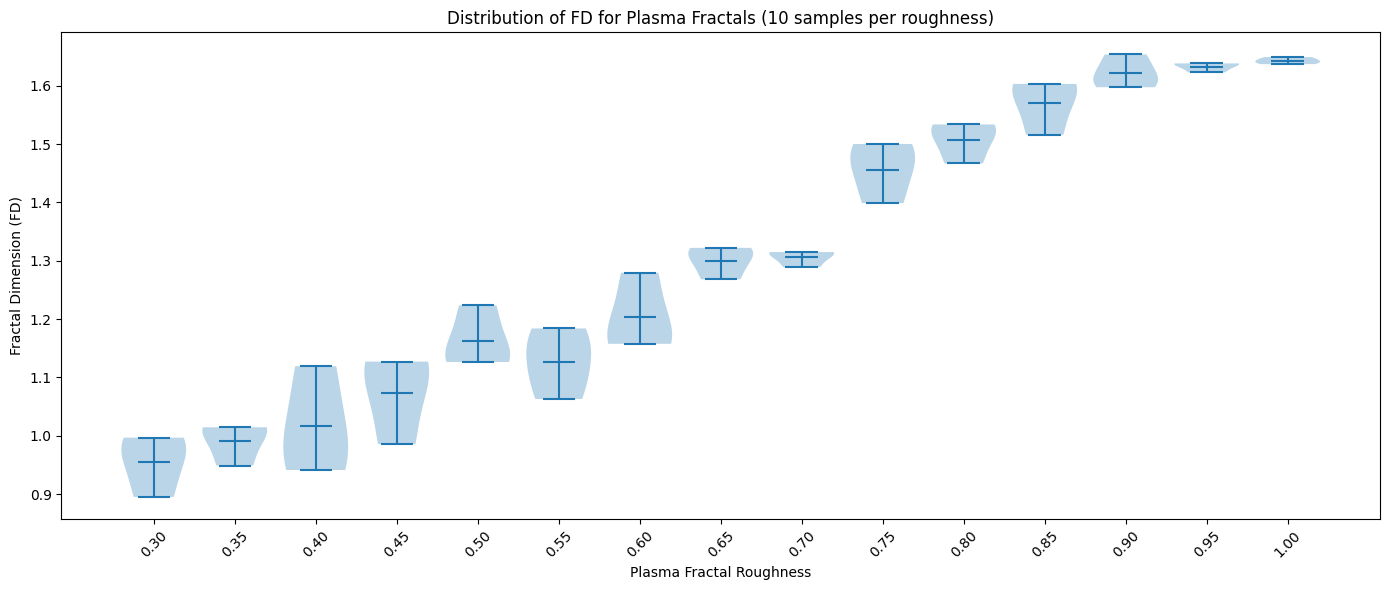

In [74]:
import matplotlib.pyplot as plt

# Range of roughness values (e.g., from smooth to rough)
roughness_values = np.arange(0.3, 1.01, 0.05)   # try [0.3, 1.0]
fd_results = []

for roughness in roughness_values:
    fd_r = []
    for i in range(3):
        print(f"Generating plasma fractal with roughness {roughness:.2f}, sample {i+1}/10")
        img = plasma_fractal(size=257, roughness=roughness, seed=None)
        binary = (img > 0.5).astype(np.float32)
        fd = fractal_dimension(binary, threshold=0.5)
        fd_r.append(fd)
    fd_results.append(fd_r)

plt.figure(figsize=(14,6))
plt.violinplot(fd_results, showmeans=True, widths=0.8)
plt.xticks(np.arange(1, len(roughness_values)+1), [f"{r:.2f}" for r in roughness_values], rotation=45)
plt.xlabel(r"Plasma Fractal Roughness")
plt.ylabel("Fractal Dimension (FD)")
plt.title("Distribution of FD for Plasma Fractals (10 samples per roughness)")
plt.tight_layout()
plt.show()


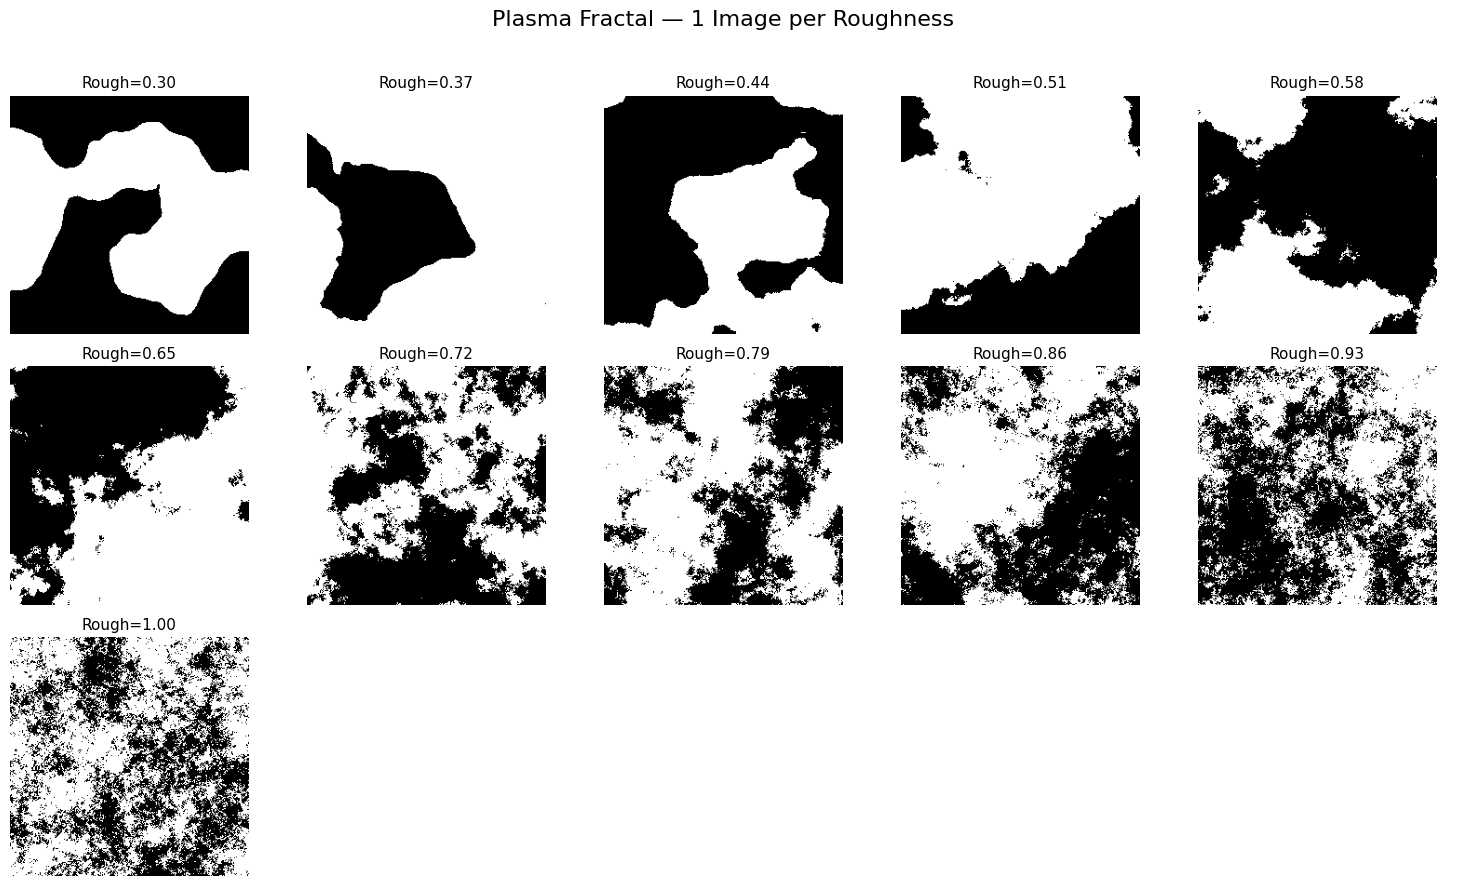

In [78]:
# --- Show one image per roughness ---
roughness_values = np.arange(0.3, 1.01, 0.07)
n_cols = min(5, len(roughness_values))
n_rows = int(np.ceil(len(roughness_values) / n_cols))

fig, axes = plt.subplots(n_rows, n_cols, figsize=(3*n_cols, 3*n_rows))
axes = axes.flatten()

for i, roughness in enumerate(roughness_values):
    img = plasma_fractal(size=257, roughness=roughness, seed=None)
    binary = (img > 0.5).astype(np.float32)
    axes[i].imshow(binary, cmap='gray', vmin=0, vmax=1)
    axes[i].set_title(f"Rough={roughness:.2f}", fontsize=11)
    axes[i].axis('off')

for j in range(i+1, len(axes)):
    axes[j].axis('off')

plt.suptitle("Plasma Fractal — 1 Image per Roughness", fontsize=16)
plt.tight_layout(rect=[0,0,1,0.96])
plt.show()